#Modelado espacial de la susceptibilidad a inundaciones usando algoritmos de aprendizaje automatico con datos de google earth engine

Autor: Sebastian Velosa Bohorquez
Curso: Percepción Remota
Herramientas: Google Earth Engine + GPBoost

Este notebook presenta una aplicación para el modelado espacial de susceptibilidad a inundaciones usando el algoritmo GPBoost tomando variables predictoras derivadas de datos obtenidos en Google Earth Engine

El flujo metodológico incluye:

Extracción de datos en Google Earth Engine.
Construcción de variables predictoras
Entrenamiento de un modelo GPBoost.
Evaluación espacial de resultados.

In [2]:
!pip install gpboost
!pip install gdown
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.2 MB/s eta 0:00:00


In [7]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import gpboost as gpb
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
SEED = 42
np.random.seed(SEED)

#2. Datos

Subir archivo csv con el data set de entrenamiento

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Asset05_AllSamples.csv to Asset05_AllSamples.csv


In [11]:
df = pd.read_csv("Asset05_AllSamples.csv")
print("\nVisualización de Datos:")
df.head()


Visualización de Datos:


,system:index,BuiltUp,Curvature,DistRiver,Elevation,Flood,FlowAccum,HAND,LandCover,NDVI,NDWI,Slope,random,.geo
0,0,13.149684,1.310745,3.755876e+03,25.598917,0,0.012567,10.177879,30.0,0.520460,-0.547497,1.689509,0.357032,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,13.315194,-0.808748,1.897367e+02,14.691923,0,0.009304,1.870944,30.0,0.621445,-0.584358,0.947346,0.375799,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0.000000,22.938599,6.855837e+03,92.570210,0,0.008453,25.550755,30.0,0.688583,-0.661164,13.054238,0.388908,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0.000000,-8.064232,2.700000e+02,32.838337,0,0.013641,2.722030,30.0,0.660310,-0.623167,3.715998,0.485591,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0.000000,-3.753613,1.390228e+06,36.250538,0,0.085103,0.352568,30.0,0.348674,-0.436784,2.992882,0.319764,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


# 3. Obtención de datos

In [12]:
def extract_coords(geo):
    geo_json = json.loads(geo)
    lon, lat = geo_json["coordinates"]
    return pd.Series([lat, lon])

df[["lat", "lon"]] = df[".geo"].apply(extract_coords)

In [13]:
def get_coords(geo):
    geom = json.loads(geo)
    coords = geom["coordinates"]
    return coords[0], coords[1]

df["lon"], df["lat"] = zip(*df[".geo"].apply(get_coords))

In [14]:
flooded = df[df["Flood"] == 1]
non_flooded = df[df["Flood"] == 0]

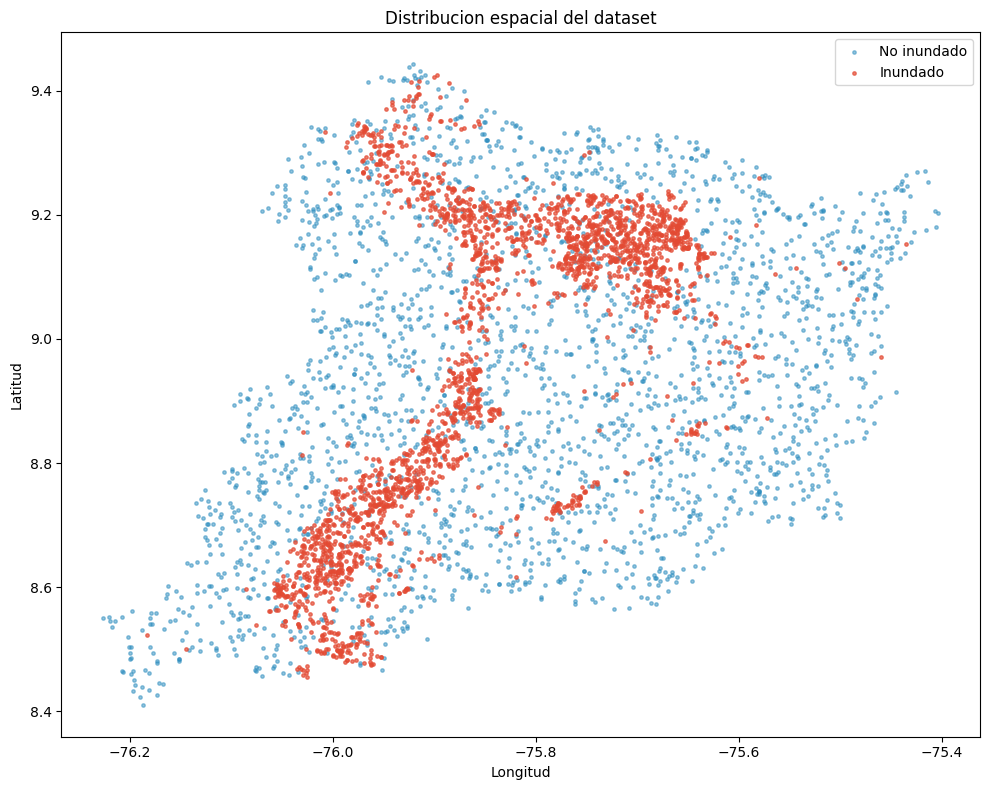

In [15]:
plt.figure(figsize=(10,8))

plt.scatter(non_flooded["lon"], non_flooded["lat"],
            s=6, c="#2b8cbe", alpha=0.5, label="No inundado")

plt.scatter(flooded["lon"], flooded["lat"],
            s=6, c="#e34a33", alpha=0.7, label="Inundado")

plt.title("Distribucion espacial del dataset")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.tight_layout()

plt.show()

In [16]:
print("\nVisualización de Datos:")
df.head()


Visualización de Datos:


,system:index,BuiltUp,Curvature,DistRiver,Elevation,Flood,FlowAccum,HAND,LandCover,NDVI,NDWI,Slope,random,.geo,lat,lon
0,0,13.149684,1.310745,3.755876e+03,25.598917,0,0.012567,10.177879,30.0,0.520460,-0.547497,1.689509,0.357032,"{""geodesic"":false,""type"":""Point"",""coordinates""...",9.116078,-75.886808
1,1,13.315194,-0.808748,1.897367e+02,14.691923,0,0.009304,1.870944,30.0,0.621445,-0.584358,0.947346,0.375799,"{""geodesic"":false,""type"":""Point"",""coordinates""...",8.825012,-75.859914
2,2,0.000000,22.938599,6.855837e+03,92.570210,0,0.008453,25.550755,30.0,0.688583,-0.661164,13.054238,0.388908,"{""geodesic"":false,""type"":""Point"",""coordinates""...",8.640908,-76.125042
3,3,0.000000,-8.064232,2.700000e+02,32.838337,0,0.013641,2.722030,30.0,0.660310,-0.623167,3.715998,0.485591,"{""geodesic"":false,""type"":""Point"",""coordinates""...",8.485643,-75.950171
4,4,0.000000,-3.753613,1.390228e+06,36.250538,0,0.085103,0.352568,30.0,0.348674,-0.436784,2.992882,0.319764,"{""geodesic"":false,""type"":""Point"",""coordinates""...",8.609797,-75.756096


#4. Configuración del entorno

Preparación de variables para el modelo

In [17]:
# Variables predictoras
features = [
    'BuiltUp', 'Curvature', 'DistRiver', 'Elevation', 'FlowAccum', 'HAND',
       'LandCover', 'NDVI', 'NDWI', 'Slope'
]

X = df[features]

# Variable objetivo
y = df["Flood"]

# Coordenadas espaciales

coords = df[["lon", "lat"]].values

print(X.columns)

Index(['BuiltUp', 'Curvature', 'DistRiver', 'Elevation', 'FlowAccum', 'HAND',
       'LandCover', 'NDVI', 'NDWI', 'Slope'],
      dtype='object')


Separación datos de entrenamiento/prueba (train/test)

In [18]:
X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X,
    y,
    coords,
    test_size=0.3,
    random_state=42
)

print("\nDatos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)


Datos entrenamiento: (3500, 10)
Datos prueba: (1500, 10)


#Modelo GPBoost

In [19]:
#Modelo
gp_model = gpb.GPModel(
    gp_coords=coords_train,
    cov_function="exponential"
)

In [20]:
# Dataset de entrenamiento
train_data = gpb.Dataset(
    X_train,
    label=y_train
)

Parámetros del modelo

In [21]:
params = {
    "objective": "regression_l2",
    "learning_rate": 0.05,
    "max_depth": 3,
    "verbose": 1
}

Entrenamiento del modelo GP Boost

In [20]:
bst = gpb.train(
    params=params,
    train_set=train_data,
    gp_model=gp_model,
    num_boost_round=20
)

print("\nModelo entrenado correctamente.")

gp_model.summary()  #parámetros espaciales estimados.



[GPBoost] [Info] Total Bins 2187
[GPBoost] [Info] Number of data points in the train set: 3500, number of used features: 10
[GPBoost] [Info] [GPBoost with gaussian likelihood]: initscore=0.505143
[GPBoost] [Info] Start training from score 0.505143

Modelo entrenado correctamente.
Model summary:
Nb. observations: 3500
Covariance parameters (random effects):
           Param.  Std. err.
Error_var  0.0472     0.0016
GP_var     0.1120     0.0269
GP_range   0.1179     0.0315


Predicción

In [44]:
pred = bst.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=True,
    pred_latent=True
)

# Predicción final y=F(X)+b(s)
y_pred = pred["fixed_effect"] + pred["random_effect_mean"]

# Efecto fijo (boosting) - y=F(X)
fixed_effect = pred["fixed_effect"]

# Efecto espacial GP - b(s)
gp_effect = pred["random_effect_mean"]

# Covarianza espacial
gp_cov = pred["random_effect_cov"]

# Incertidumbre espacial
gp_std = np.sqrt(gp_cov)

Evaluación del Modelo

In [53]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMÉTRICAS")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MÉTRICAS
RMSE: 0.28
R²: 0.682


#Matriz de Confusión

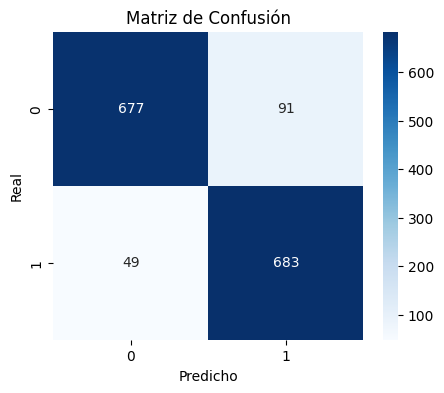

In [45]:
from sklearn.metrics import confusion_matrix

# Convert continuous predictions to binary (0 or 1) using a threshold
y_pred_binary = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

In [46]:
from sklearn.metrics import accuracy_score, classification_report

# Convert continuous predictions to binary (0 or 1) using a threshold
y_pred_binary = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print(classification_report(y_test, y_pred_binary))

Accuracy: 0.9066666666666666
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       768
           1       0.88      0.93      0.91       732

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



AUC: 0.9571308629326047


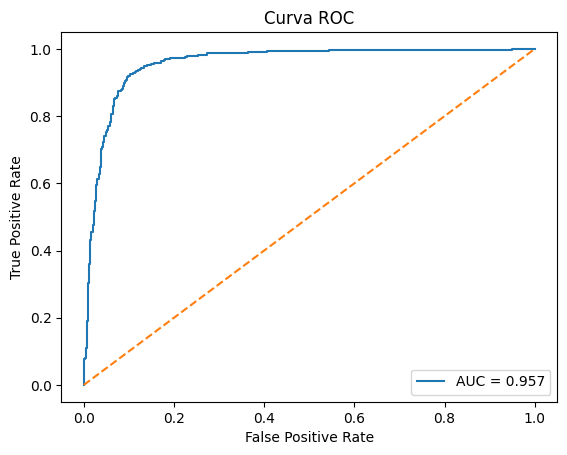

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label="AUC = " + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

# IMPORTANCIA DE VARIABLES




In [36]:
print("\nCalculando valores SHAP...")

explainer = shap.TreeExplainer(bst)

shap_values = explainer.shap_values(X_test)


Calculando valores SHAP...


Gráfico resumen SHAP

/tmp/ipykernel_15875/219860562.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


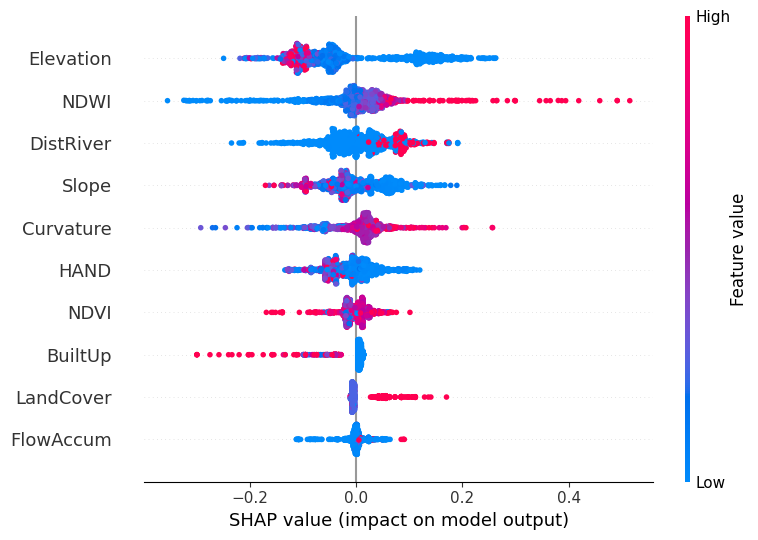

In [37]:
shap.summary_plot(
    shap_values,
    X_test
)

/tmp/ipykernel_15875/3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


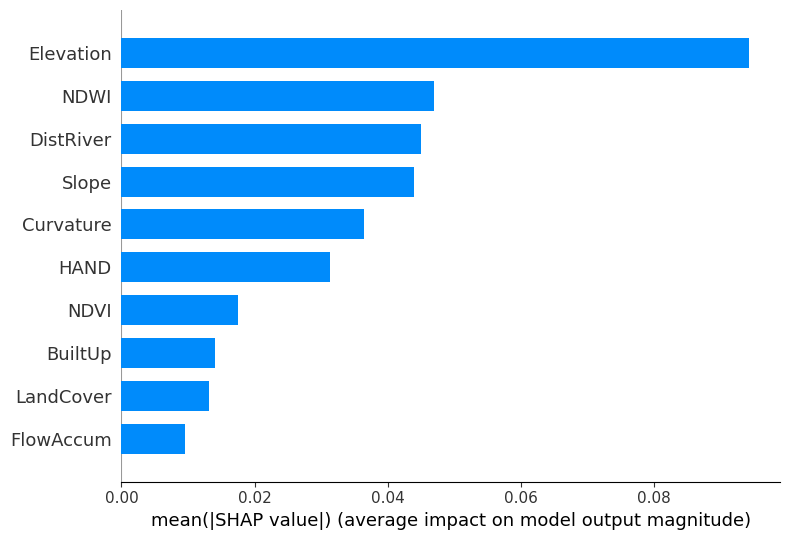

In [40]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Comparación de métricas contra otros modelos

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=SEED,
    n_jobs=-1
)

Entrenamiento

In [35]:
rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=20, n_estimators=500, n_jobs=-1,
                      random_state=42)

Predicción

In [55]:
y_pred = rf.predict(X_test)


Métricas

In [56]:
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_rf = r2_score(
    y_test,
    y_pred
)
print("\nMÉTRICAS")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.3f}")


MÉTRICAS
RMSE: 0.31
R²: 0.606


Comparación de resultados

In [58]:
results = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "GPBoost"
    ],
    "RMSE": [
        rmse_rf,
        rmse
    ],
    "R2": [
        r2_rf,
        r2
    ]
})

print("\n========== COMPARACIÓN MODELOS ==========")
display(results)


========== COMPARACIÓN MODELOS ==========


,Modelo,RMSE,R2
0,Random Forest,0.313632,0.606312
1,GPBoost,0.281731,0.682328


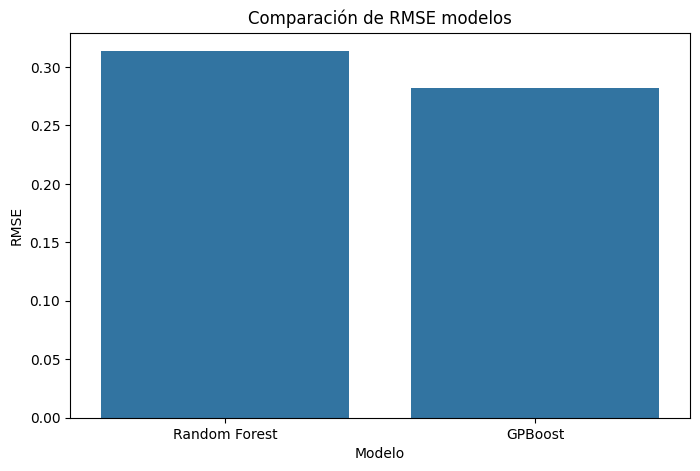

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Modelo",
    y="RMSE"
)

plt.title("Comparación de RMSE modelos")

plt.ylabel("RMSE")

plt.show()

# Guardar el modelo

In [26]:
bst.save_model(
    "gpboost_model.json"
)

NameError: name 'bst' is not defined

In [42]:
files.download(
    "gpboost_model.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cómo cargar un modelo GPBoost entrenado

Para cargar un modelo `gpboost` ya entrenado, puedes utilizar la clase `gpb.Booster` y pasar la ruta al archivo del modelo guardado utilizando el parámetro `model_file`. Es crucial que el archivo del modelo (`gpboost_model.json` en este caso) exista en el entorno de Colab en el momento de la carga. Si el archivo no está presente, se producirá un `FileNotFoundError`.

Asegúrate de haber ejecutado previamente la celda que guarda el modelo (`bst.save_model("gpboost_model.json")`) antes de intentar cargarlo, y que el archivo no haya sido eliminado o el entorno de ejecución reiniciado sin guardar el archivo en un lugar persistente.

### (opcional) Subir un archivo GP_model desde tu PC a Colab

---



Para subir tu archivo de modelo (o cualquier otro archivo) desde tu PC a Colab, puedes usar la función `files.upload()`. Esta función te permitirá seleccionar el archivo desde tu explorador de archivos local. Una vez subido, el archivo estará disponible en el entorno de Colab.

In [27]:
from google.colab import files

# Usa files.upload() para seleccionar y subir tu archivo de modelo (por ejemplo, 'gpboost_model.json')
# Se abrirá una ventana para que elijas el archivo de tu computadora.
uploaded_model = files.upload()

Saving gpboost_model.json to gpboost_model.json


In [29]:
import gpboost as gpb

# Cargar el modelo desde el archivo guardado
try:
    loaded_bst = gpb.Booster(
        model_file="gpboost_model.json"
    )
    print("Modelo GPBoost cargado exitosamente!")
except FileNotFoundError:
    print("Error: El archivo 'gpboost_model.json' no se encontró. Asegúrate de haber guardado el modelo previamente.")
except Exception as e:
    print(f"Ocurrió un error al cargar el modelo: {e}")

Finished loading model, total used 20 iterations
Modelo GPBoost cargado exitosamente!


In [30]:
bst = gpb.Booster(
    model_file="gpboost_model.json"
)

Finished loading model, total used 20 iterations
